```
ME72: Maestría en Métodos Cuantitativos para la Gestión y Análisis de Datos
M72109: Analisis de datos no estructurados
Universidad de Buenos Aires - Facultad de Ciencias Economicas (UBA-FCE)
Año: 2026
Profesor: Facundo Santiago, Javier Ignacio Garcia Fronti
Maestrando: Lucas Enzo Pérez
```


# Desafio de memorabilidad: Computer Vision

Como trabajo final para la materia, les proponemos resolver un desafio de memorabilidad de un video, el cual requerirá de utilizar todos los conceptos que revisamos en la materia **al mismo tiempo**: imagenes, audio y texto.

## ¿De que se trata el desafío?

Esta tarea se centra en el problema de predecir qué tan memorable es un video para un espectador. Definiremos a un video como memorable como la probabilidad de que se recuerde tal video luego de un lapso de tiempo determinado.

Recibirán un extenso conjunto de datos de videos que van acompañados de anotaciones memorables, así como predictores (features) extraídos previamente que reflejan distintos preprocesamientos de los videos para que la tarea le resulte más sencilla. Las etiquetas (labels) se ha recopilado a través de pruebas de reconocimiento y, por lo tanto, es el resultado de una medición objetiva del rendimiento de la memoria.

<img src='https://raw.githubusercontent.com/santiagxf/M72109/master/Desafio/Docs/memorability.PNG' width=600 />

*Creditos del desafio original:*

http://www.multimediaeval.org/mediaeval2019/memorability/

Mihai Gabriel Constantin, University Politehnica of Bucharest, Romania
Bogdan Ionescu, University Politehnica of Bucharest, Romania
Claire-Hélène Demarty, Technicolor, France
Quang-Khanh-Ngoc Duong, Technicolor, France
Xavier Alameda-Pineda, INRIA, France
Mats Sjöberg, CSC, Finland

Para mas información sobre esta tarea, puede revisar [Overview of The MediaEval 2021 Predicting Media Memorability Task](https://arxiv.org/abs/2112.05982)

## Direcciones

Deberán entrenar modelos de aprendizaje automático capaces de inferir la memorabilidad de video a partir del contenido **de imagenes**.

Utilizando estos datos, deberán evaluar la performance del modelo utilizando un set de datos de evaluación. Los modelos se evaluarán a través de métricas de evaluación estándar utilizadas en las tareas de clasificación y regresión (dependiendo del tipo de desafío que elijan).

Cuentan con 2 tipos de anotaciones para cada uno de los fragmentos de video disponibles:
 - **memorability_score:** Representa el puntaje de memorabilidad de la secuencia en particular, desde 0 a 1. Valores más grandes son mejores.
 - **memorable:** Variable categórica que representa si un video es memorable o no. Un video con `memorability_score` superior a `0.5` es marcado como memorable (`1`), sino es marcado como no memorable (`0`)

 > Note que aquí nuestras muestras son "secuencias" de determinadas películas. En total dispone de 660 secuencias con el nombre `sequence_name`. El mismo nombre se generó automáticamente concatenando el nombre de la pelicula a la que pertenece la secuencia (movie_name), seguido del segundo en el que comienza la secuencia, seguido del segundo en el que termina, seguido de un numero que indica el número de secuencia. Por ejemplo, la secuencia `127_hours_2000_2010_1` es un fragmento de la pelicula "127 hours", que va desde el segundo 2000 (00:33:20 hrs.) al segundo 2010 (00:33:30 hrs.) y es el fragmento número 1. Esta información es totalmente irrelevante para el problema de memorabilidad pero **el nombre de la secuencia (`sequence_name`) será su clave primeria para vincular los diferentes conjuntos de datos.**

### Entrega

Debera entregar:


2. El archivo de Colab con la solución propuesta.
3. El codigo debe:
    1. Entrenar o diseñar 1 modelo de aprendizaje automático basado en técnicas de **Computer Vision**.
    2. Poder ser ejecutable de arriba a abajo.
    3. Poder ser ejecutado sin errores.
    4. Estar claramente documentado con el paso a paso de porque realiza lo que realiza.
    5. Utilizar solo técnicas vistas en la materia.
    6. No contener código no utilizado.

4. Subir el mismo dentro de la tarea correspondiente.


## Preparación del ambiente

### Vision

In [1]:
!pip install tensorflow tensorflow-datasets fsspec
!pip install transformers datasets evaluate diffusers accelerate
!pip matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00
ERROR: unknown command "matplotlib"


In [2]:
pip install matplotlib

### Sets de datos

Descargamos el set de datos:

In [3]:
!wget https://raw.githubusercontent.com/santiagxf/M72109/refs/heads/master/Desafio/Data/ground_truth.csv --directory-prefix ./Data/ --quiet --no-clobber
!wget https://santiagxf.blob.core.windows.net/public/Memorability/frames.zip --directory-prefix ./Data/Features/ --quiet --no-clobber

Descompromimos los archivos

In [4]:
!unzip -qo /content/Data/Features/frames.zip -d /content/Data/Features/frames

Los conjuntos de datos utilizados en este desafío son los siguientes:

*   `ground_truth.csv`: Contiene la verdad fundamental para el problema de clasificación. Este archivo incluye información sobre segmentos de video (`movie_name`, `start(sec)`, `end(sec)`) y su correspondiente puntuación de memorabilidad (`memorability_score`). **Aunque contiene varias columnas, para el problema de clasificación que abordaremos, la columna clave es `memorable`, que indica la probabilidad de que una persona recuerde el video.**
* Directorio `Data/Features/frames`: En lugar de trabajar con videos, hemos extraido cuadros (frames) de cada uno de los videos disponibles. Dispone de:

    *   **4 frames:** uno en el segundo 0, otro en el segundo 52, otro en el segundo 112, y un frame adicional que corresponde al que tiene la mayor cantidad de información (determinado por el método del histograma).
    *   **Nomenclatura de los frames:** Cada frame se nombra como `<sequence>__<frame>.jpg`, donde `<frame>` puede ser `0`, `52`, `112`, o `histograma`.
*   **Valores de verdad (labels):** Los valores de verdad para la memorabilidad (`memorability_score` y `memorable`) continúan estando definidos por cada secuencia completa.

**IMPORTANTE: Para proceder con el análisis, será necesario combinar estas etiquetas (`ground_truth.csv`) con los frames en el directorio /Data/Features/frames. NO ES NECESARIO que utilize los 4 frames disponibles al mismo tiempo. Puede utilizar 1, multiples, o comparar varias alternativas (por ejemplo, verificar cual de todos los frames aporta el mejor resultado).**

In [5]:
import pandas as pd

labels = pd.read_csv('Data/ground_truth.csv')

### Tip: Preparación de datos para Computer Vision

La siguiente rutina muestra un ejemplo para recopilar las rutas de todas las imágenes de los *frames* y las asociaremos con sus `sequence_name` correspondientes del archivo `ground_truth.csv`.

In [6]:
import os
import glob
import numpy as np
import tensorflow as tf
import pandas as pd

# Directorio donde se encuentran los frames extraídos
frames_dir = '/content/Data/Features/frames/'

# Obtener todas las rutas de los archivos .jpg en el directorio de frames
all_image_paths = glob.glob(os.path.join(frames_dir, '*.jpg'))

# Extraer los 'sequence_name' de las rutas de las imágenes
# El formato de nombre de archivo es <sequence_name>__<frame_type>.jpg
image_sequence_names = [os.path.basename(path).split('__')[0] for path in all_image_paths]

# Crear un DataFrame con las rutas de las imágenes y sus sequence_name
image_df = pd.DataFrame({
    'sequence_name': image_sequence_names,
    'image_path': all_image_paths
})

# Unir con el DataFrame de labels para obtener los valores de verdad
# Nos enfocaremos en la columna 'memorable' y 'memorability_score'
dataset_df = pd.merge(image_df, labels[['sequence_name', 'memorable', 'memorability_score']], on='sequence_name', how='inner')

print(f"\nTotal de imágenes encontradas: {len(all_image_paths)}")
print(f"Total de entradas de datos con labels (tras la unión): {len(dataset_df)}")
display(dataset_df.head())


Total de imágenes encontradas: 2640
Total de entradas de datos con labels (tras la unión): 2640


,sequence_name,image_path,memorable,memorability_score
0,Toni_Erdmann_4283_4293_247,/content/Data/Features/frames/Toni_Erdmann_428...,0,0.000000
1,Snake_Eyes_3294_3304_170,/content/Data/Features/frames/Snake_Eyes_3294_...,0,0.000000
2,Fantastic_Four_1_4248_4258_3,/content/Data/Features/frames/Fantastic_Four_1...,1,0.785714
3,Birdman_3164_3174_29,/content/Data/Features/frames/Birdman_3164_317...,0,0.285714
4,The_Dark_Knight_Rises_3827_3837_23,/content/Data/Features/frames/The_Dark_Knight_...,1,0.666667


## Solución

memorable
0    0.560606
1    0.439394
Name: proportion, dtype: float64


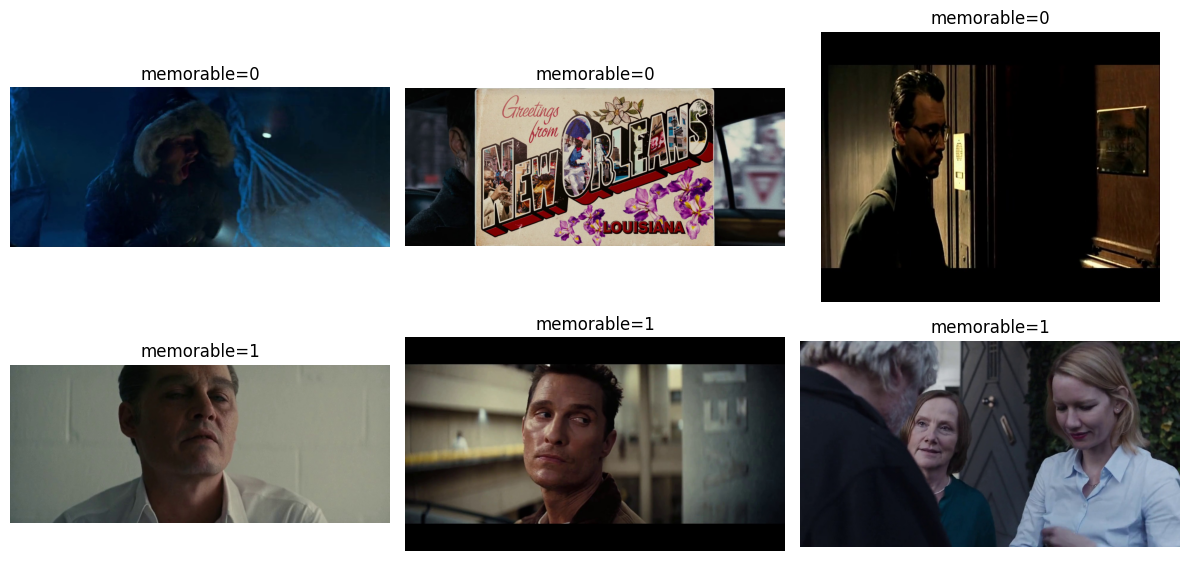

In [7]:
print(dataset_df['memorable'].value_counts(normalize=True))

import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i, label in enumerate([0, 1]):
    sample = dataset_df[dataset_df['memorable'] == label].sample(3, random_state=0)
    for j, path in enumerate(sample['image_path']):
        axes[i, j].imshow(Image.open(path))
        axes[i, j].set_title(f"memorable={label}")
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()

el dataset tiene 56.1% de secuencias no memorables (memorable=0) y 43.9% memorables (memorable=1). La diferencia es leve, por lo que no es necesario aplicar técnicas de balanceo de clases (como pesos por clase o sobremuestreo); un modelo entrenado sin ajustes adicionales no debería sesgarse significativamente hacia la clase mayoritaria. as imágenes de ambas clases muestran escenas diversas (interiores, exteriores, primeros planos, paisajes urbanos), sin un patrón evidente a simple vista que distinga "memorable" de "no memorable". Esto confirma que se trata de un problema no trivial, apropiado para un modelo de deep learning que aprenda features relevantes por sí mismo.

2)

In [8]:
from sklearn.model_selection import train_test_split

sequences = dataset_df[['sequence_name', 'memorable']].drop_duplicates()

train_seq, test_seq = train_test_split(
    sequences['sequence_name'],
    test_size=0.2,
    stratify=sequences['memorable'],
    random_state=0
)

train_df = dataset_df[dataset_df['sequence_name'].isin(train_seq)]
test_df = dataset_df[dataset_df['sequence_name'].isin(test_seq)]

print("Secuencias train:", train_seq.shape[0], "| Secuencias test:", test_seq.shape[0])
print("Filas train:", len(train_df), "| Filas test:", len(test_df))
print("Interseccion sequence_name (debe ser 0):",
      len(set(train_df.sequence_name) & set(test_df.sequence_name)))

Secuencias train: 528 | Secuencias test: 132
Filas train: 2112 | Filas test: 528
Interseccion sequence_name (debe ser 0): 0


se dividió por sequence_name (no por fila) para evitar que frames de una misma secuencia queden repartidos entre train y test, lo cual generaría data leakage. Resultado: 528 secuencias (2112 imágenes) en train y 132 secuencias (528 imágenes) en test, sin intersección entre ambos conjuntos.

# 3

In [9]:
train_hist = train_df[train_df['image_path'].str.contains('__histogram')].reset_index(drop=True)
test_hist = test_df[test_df['image_path'].str.contains('__histogram')].reset_index(drop=True)

print("Train (histogram):", len(train_hist), "| Test (histogram):", len(test_hist))
print(train_hist[['sequence_name', 'image_path', 'memorable']].head())

Train (histogram): 528 | Test (histogram): 132
                 sequence_name  \
0         Birdman_3164_3174_29   
1         The_Mask_2923_2933_9   
2      Fight_Club_2235_2245_18   
3    Batman_Begins_1243_1253_2   
4  Never_Let_Me_Go_3289_3299_1   

                                          image_path  memorable  
0  /content/Data/Features/frames/Birdman_3164_317...          0  
1  /content/Data/Features/frames/The_Mask_2923_29...          0  
2  /content/Data/Features/frames/Fight_Club_2235_...          1  
3  /content/Data/Features/frames/Batman_Begins_12...          0  
4  /content/Data/Features/frames/Never_Let_Me_Go_...          1  


**se usa un único frame por secuencia, el marcado como histogram (el de mayor información según el método de histograma). Resultado: 528 imágenes en train y 132 en test, una por secuencia, coincidiendo con la cantidad de secuencias del split anterior.**

# 4

In [10]:
IMG_SIZE = 224

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((train_hist['image_path'], train_hist['memorable']))
train_ds = train_ds.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_hist['image_path'], test_hist['memorable']))
test_ds = test_ds.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)

for imgs, labels in train_ds.take(1):
    print(imgs.shape, labels.shape)
    print("min/max pixel:", imgs.numpy().min(), imgs.numpy().max())

(32, 224, 224, 3) (32,)
min/max pixel: 0.0 255.0


**se construyó un tf.data.Dataset que carga cada imagen desde disco, la redimensiona a 224×224 (tamaño esperado por ResNet50) y arma lotes de 32. Se verificó el shape de un batch: (32, 224, 224, 3) para las imágenes y (32,) para las etiquetas. Los píxeles quedan en rango [0, 255]; la normalización específica del modelo se aplica en el siguiente bloque.**

# 5

5.a

In [11]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

**se cargó el modelo preentrenado en ImageNet, sin su capa de clasificación (include_top=False). Tiene ~23.6M parámetros y transforma cada imagen 224×224×3 en un mapa de características de forma (7, 7, 2048). Por defecto todos los parámetros figuran como entrenables — en el siguiente paso los congelamos para usarlo solo como extractor de features.**

5.b

In [12]:
base_model.trainable = False
print("Trainable params:", sum(p.numpy().size for p in base_model.trainable_weights))


Trainable params: 0


**se fijó trainable = False en ResNet50, dejando sus 23.6M parámetros congelados (0 entrenables). Así el modelo actúa como extractor de features fijo, aprovechando lo aprendido en ImageNet sin riesgo de sobreajustar con nuestro dataset chico (528 imágenes de train).**

5.c y d

In [13]:
from tensorflow.keras.applications.resnet50 import preprocess_input

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Lambda(preprocess_input),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,718,913 (90.48 MB)

 Trainable params: 131,201 (512.50 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

**ResNet50 congelada (23.5M params fijos) + GlobalAveragePooling2D (reduce 7×7×2048 a un vector de 2048) + Dense(64, relu) + Dense(1, sigmoid) para clasificación binaria. Solo se entrenan 131,201 parámetros (0.55% del total), lo cual es apropiado dado el tamaño chico del dataset (528 imágenes de train): evita overfitting al no reentrenar toda la red.**

# 6

In [15]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 7

In [16]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 27s 855ms/step - accuracy: 0.5436 - loss: 0.8096 - val_accuracy: 0.5606 - val_loss: 0.7123
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.6080 - loss: 0.6325 - val_accuracy: 0.5530 - val_loss: 0.7600
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.6307 - loss: 0.6217 - val_accuracy: 0.5530 - val_loss: 0.7094
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.6572 - loss: 0.6008 - val_accuracy: 0.5909 - val_loss: 0.6905
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.6989 - loss: 0.5560 - val_accuracy: 0.5682 - val_loss: 0.7241
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - accuracy: 0.7235 - loss: 0.5132 - val_accuracy: 0.5530 - val_loss: 0.7307
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.7367 - loss: 0.4932 - val_accuracy: 0.5606 - val_loss: 0.7932
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.8144 - loss: 0.4324 - val_accuracy: 0

**overfitting evidente. La accuracy de train sube de 0.54 a 0.84 en 10 épocas, pero la de validación se mantiene plana entre 0.55-0.59 (val_loss incluso empeora). El modelo está memorizando las 528 imágenes de entrenamiento sin aprender patrones generalizables. Es un resultado esperado con un dataset chico; en los próximos pasos evaluamos con más detalle y probamos mitigarlo (menos épocas, regularización o data augmentation).**

# 8

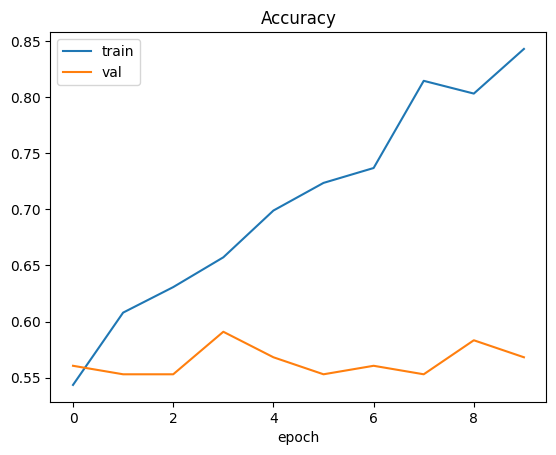

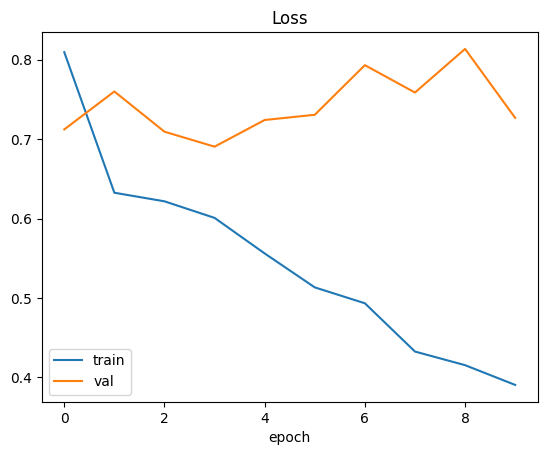

In [17]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

Primero: confirman el overfitting. Train sube de forma sostenida hasta 0.84, mientras que val se mantiene siempre entre 0.55-0.59, sin tendencia de mejora. La brecha creciente entre ambas curvas es la firma clásica de un modelo que memoriza en vez de generalizar.

Segundo: train baja de forma continua (0.81→0.39), pero val toca su mínimo en la época 3 (~0.69) y luego empeora con oscilaciones. Esto marca la época 3 como el punto óptimo antes de empezar a sobreajustar — entrenar más allá de eso solo empeora la generalización.

# 9

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = test_hist['memorable'].values
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob > 0.5).astype(int)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
[[55 19]
 [38 20]]
              precision    recall  f1-score   support

           0       0.59      0.74      0.66        74
           1       0.51      0.34      0.41        58

    accuracy                           0.57       132
   macro avg       0.55      0.54      0.54       132
weighted avg       0.56      0.57      0.55       132



accuracy 57%, apenas por encima de un baseline trivial (predecir siempre la clase mayoritaria da ~56%). La matriz de confusión muestra que el modelo falla más en detectar la clase "memorable" (recall 0.34) que la "no memorable" (recall 0.74) — tiende a sesgarse hacia predecir "no memorable". Esto confirma que el modelo con 10 épocas no aprendió señal útil, consistente con el overfitting visto en las curvas.

# 10

In [19]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history2 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 740ms/step - accuracy: 0.8504 - loss: 0.3544 - val_accuracy: 0.5833 - val_loss: 0.8254
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.9223 - loss: 0.2679 - val_accuracy: 0.5758 - val_loss: 0.9056
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.9545 - loss: 0.2208 - val_accuracy: 0.5909 - val_loss: 0.9601
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.9659 - loss: 0.1920 - val_accuracy: 0.5833 - val_loss: 1.0354


### Esta bien este resultado pero creo que debi reconstruir el modelo

In [20]:
base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Lambda(preprocess_input),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history2 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 730ms/step - accuracy: 0.5246 - loss: 0.8646 - val_accuracy: 0.5682 - val_loss: 0.7552
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - accuracy: 0.5549 - loss: 0.6894 - val_accuracy: 0.4773 - val_loss: 0.7094
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - accuracy: 0.6269 - loss: 0.6473 - val_accuracy: 0.5303 - val_loss: 0.6993
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.6420 - loss: 0.6152 - val_accuracy: 0.5530 - val_loss: 0.7332
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - accuracy: 0.6515 - loss: 0.5960 - val_accuracy: 0.5606 - val_loss: 0.7247
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.7102 - loss: 0.5596 - val_accuracy: 0.5303 - val_loss: 0.7226


**partiendo de un modelo fresco (mismos pesos iniciales que el primer entrenamiento), el early stopping detuvo el entrenamiento en la época 6 tras no mejorar el val_loss durante 3 épocas consecutivas, y restauró los pesos de la época 3 (val_loss mínimo: 0.699, val_accuracy: 0.53). Este modelo generaliza levemente peor en val_accuracy que dejarlo correr más, pero evita seguir sobreajustando innecesariamente.**

# 11

In [21]:
y_prob2 = model.predict(test_ds).ravel()
y_pred2 = (y_prob2 > 0.5).astype(int)

print(confusion_matrix(y_true, y_pred2))
print(classification_report(y_true, y_pred2))

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
[[61 13]
 [49  9]]
              precision    recall  f1-score   support

           0       0.55      0.82      0.66        74
           1       0.41      0.16      0.23        58

    accuracy                           0.53       132
   macro avg       0.48      0.49      0.44       132
weighted avg       0.49      0.53      0.47       132



**el modelo con early stopping (53% accuracy) generalizó peor que el sobreajustado de 10 épocas (57% accuracy), y quedó sesgado casi por completo hacia predecir "no memorable" (recall clase 1: 0.16). Conclusión: ninguno de los dos enfoques logra una señal útil. El problema no es solo el momento de frenar el entrenamiento — con ResNet50 congelada y un solo frame por secuencia, el modelo no está capturando información suficiente para distinguir memorabilidad.**

In [22]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    tf.keras.layers.Lambda(preprocess_input),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history3 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 368ms/step - accuracy: 0.5265 - loss: 0.8508 - val_accuracy: 0.5606 - val_loss: 0.7208
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step - accuracy: 0.5682 - loss: 0.6805 - val_accuracy: 0.5606 - val_loss: 0.6906
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 221ms/step - accuracy: 0.6439 - loss: 0.6509 - val_accuracy: 0.5379 - val_loss: 0.6867
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.6193 - loss: 0.6426 - val_accuracy: 0.5303 - val_loss: 0.7052
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 220ms/step - accuracy: 0.6496 - loss: 0.6089 - val_accuracy: 0.5530 - val_loss: 0.6933
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.6667 - loss: 0.5946 - val_accuracy: 0.5682 - val_loss: 0.7274


**el early stopping restauró los pesos de la época 3 (val_loss: 0.687, val_accuracy: 0.538), levemente mejor que sin augmentation (val_loss: 0.699). El train accuracy crece más lento que antes, señal de que el augmentation está frenando el overfitting como se esperaba. Falta confirmar si esto se traduce en mejor performance real en el set de test.**

# 13

In [23]:
y_prob3 = model.predict(test_ds).ravel()
y_pred3 = (y_prob3 > 0.5).astype(int)

print(confusion_matrix(y_true, y_pred3))
print(classification_report(y_true, y_pred3))

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 717ms/step
[[41 33]
 [28 30]]
              precision    recall  f1-score   support

           0       0.59      0.55      0.57        74
           1       0.48      0.52      0.50        58

    accuracy                           0.54       132
   macro avg       0.54      0.54      0.53       132
weighted avg       0.54      0.54      0.54       132



**accuracy 54%, similar a los intentos anteriores, pero con una diferencia importante porque las predicciones ahora están balanceadas entre ambas clases (recall 0.55 y 0.52), a diferencia del modelo anterior que colapsaba prediciendo casi siempre "no memorable" (recall 0.82 vs 0.16). El F1-score de la clase "memorable" mejoró de 0.23 a 0.50. Sigue sin superar claramente el baseline de 56%, lo que indica que el cuello de botella no es el overfitting sino la señal disponible: un solo frame estático (aunque sea el "histograma") puede no contener suficiente información visual para predecir memorabilidad.**

# 14

In [24]:
train_ds_all = tf.data.Dataset.from_tensor_slices((train_df['image_path'], train_df['memorable']))
train_ds_all = train_ds_all.map(load_image).shuffle(len(train_df)).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds_all = tf.data.Dataset.from_tensor_slices((test_df['image_path'], test_df['memorable']))
test_ds_all = test_ds_all.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)

print("Train filas:", len(train_df), "| Test filas:", len(test_df))
for imgs, labels in train_ds_all.take(1):
    print(imgs.shape, labels.shape)

Train filas: 2112 | Test filas: 528
(32, 224, 224, 3) (32,)


**se reconstruyó el pipeline usando todas las imágenes por secuencia (train_df/test_df completos) en vez de filtrar solo histogram. Train pasa de 528 a 2112 imágenes, test de 132 a 528 — cuadriplicando los datos de entrenamiento sin agregar videos nuevos, solo más vistas de los mismos.**

# 15

In [25]:
base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    tf.keras.layers.Lambda(preprocess_input),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history4 = model.fit(
    train_ds_all,
    validation_data=test_ds_all,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 34s 259ms/step - accuracy: 0.5848 - loss: 0.6837 - val_accuracy: 0.5436 - val_loss: 0.7262
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 183ms/step - accuracy: 0.6676 - loss: 0.6013 - val_accuracy: 0.5492 - val_loss: 0.7011
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 180ms/step - accuracy: 0.7216 - loss: 0.5339 - val_accuracy: 0.5284 - val_loss: 0.7572
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 183ms/step - accuracy: 0.7580 - loss: 0.4956 - val_accuracy: 0.5208 - val_loss: 0.8099
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 179ms/step - accuracy: 0.7931 - loss: 0.4574 - val_accuracy: 0.5625 - val_loss: 0.8517


**el early stopping restauró los pesos de la época 2 (val_loss: 0.701, val_accuracy: 0.549). A pesar de cuadriplicar los datos de entrenamiento, el patrón de overfitting persiste (train accuracy sube a 0.79 en 5 épocas mientras val se mantiene estancada). Esto sugiere que el problema no es solo cantidad de datos, sino que los 4 frames de una misma secuencia son muy parecidos entre sí (no aportan tanta diversidad real como 4 videos distintos).**

# 16

In [26]:
test_df = test_df.copy()
test_df['y_prob'] = model.predict(test_ds_all).ravel()

seq_pred = test_df.groupby('sequence_name').agg(
    memorable=('memorable', 'first'),
    y_prob=('y_prob', 'mean')
).reset_index()
seq_pred['y_pred'] = (seq_pred['y_prob'] > 0.5).astype(int)

print(confusion_matrix(seq_pred['memorable'], seq_pred['y_pred']))
print(classification_report(seq_pred['memorable'], seq_pred['y_pred']))

17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step
[[62 12]
 [44 14]]
              precision    recall  f1-score   support

           0       0.58      0.84      0.69        74
           1       0.54      0.24      0.33        58

    accuracy                           0.58       132
   macro avg       0.56      0.54      0.51       132
weighted avg       0.56      0.58      0.53       132



# 17

In [27]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

base = ResNet50(include_top=False, weights='imagenet',
                input_shape=(224,224,3), pooling='avg')

def load_for_embed(path):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.resize(img, [224,224])
    return preprocess_input(img)

ds = (tf.data.Dataset.from_tensor_slices(dataset_df['image_path'].tolist())
      .map(load_for_embed).batch(64))
emb = base.predict(ds, verbose=1)
print(emb.shape)

42/42 ━━━━━━━━━━━━━━━━━━━━ 32s 525ms/step
(2640, 2048)


Como `ResNet50` está congelada, sus features no cambian entre épocas entonces recalcularlos en cada pasada es trabajo repetido. Los extraemos **una sola vez** y trabajamos sobre ellos.`pooling='avg'` colapsa el mapa de activaciones (7, 7, 2048) a un vector de 2048 promediando cada canal — es la misma operación que hacía la capa `GlobalAveragePooling2D` del modelo anterior.

In [28]:
emb_df = pd.DataFrame(emb, index=dataset_df['sequence_name'])
X_df = emb_df.groupby(level=0).mean()
y_df = dataset_df.groupby('sequence_name')[['memorable', 'memorability_score']].first().loc[X_df.index]

X, y = X_df.values, y_df['memorable'].values
print(X.shape, y.shape, '| baseline:', round(max(y.mean(), 1 - y.mean()), 3))

(660, 2048) (660,) | baseline: 0.561


La etiqueta memorable está definida **por secuencia**, no por frame. Al trabajar fila por fila estábamos repitiendo la misma etiqueta 4 veces y dejando que el modelo viera 4 imágenes casi idénticas como si fueran observaciones independientes.

Acá promediamos los 4 vectores de cada secuencia en uno solo: pasamos de 2640 filas a **660 secuencias**, una observación por unidad de análisis. La agregación ahora ocurre en el espacio de *features*, no en el de predicciones como en el bloque 16.

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate

clf = make_pipeline(StandardScaler(), LogisticRegression(C=0.01, max_iter=2000))
cv = StratifiedKFold(5, shuffle=True, random_state=42)
r = cross_validate(clf, X, y, cv=cv, scoring=['accuracy', 'roc_auc'])

for m in ['accuracy', 'roc_auc']:
    s = r['test_' + m]
    print(f'{m}: {s.mean():.3f} ± {s.std():.3f}')

accuracy: 0.579 ± 0.022
roc_auc: 0.601 ± 0.028


Con el esquema anterior (un único split 80/20) el test tenía 132 secuencias y un intervalo de confianza de ±8.5 puntos: los cuatro experimentos previos (0.53 a 0.58) eran estadísticamente indistinguibles entre sí. Se comparando ruido.

Con 5-fold cada secuencia se evalúa una vez y el desvío baja a ±2.2 puntos. El dato importante es el AUC de 0.601: como no depende del umbral, confirma que los features de ResNet50 contienen señal sobre memorabilidad —débil, pero real y consistente entre folds—. La accuracy la escondía porque el umbral fijo de 0.5 no está calibrado para esta distribución.

In [31]:
movies = X_df.index.str.rsplit('_', n=3).str[0]
print('secuencias:', len(movies), '| películas:', movies.nunique())
print(movies.value_counts().head(10))

secuencias: 660 | películas: 98
sequence_name
127_hours                   7
2001_A_Space_Odyssey        7
A_History_Of_Violence       7
Amadeus                     7
Armageddon                  7
Avengers_-_Age_of_Ultron    7
Back_To_The_Future          7
Basic_Instinct              7
Batman_Begins               7
Being_John_Malkovich        7
Name: count, dtype: int64


98 películas, 7 secuencias cada una. Eso es fuga de datos: en el 5-fold actual, para cada secuencia de test hay ~6 secuencias hermanas de la misma película en train. El modelo puede reconocer el film (paleta, grano, iluminación, actores) y usar eso como atajo, porque las secuencias de una misma película tienden a compartir memorabilidad. Parte del 0.601 puede ser "reconocer películas", no "medir memorabilidad"

In [32]:
from sklearn.model_selection import StratifiedGroupKFold

cv_g = StratifiedGroupKFold(5, shuffle=True, random_state=42)
r_g = cross_validate(clf, X, y, groups=movies, cv=cv_g,
                     scoring=['accuracy', 'roc_auc'])

for m in ['accuracy', 'roc_auc']:
    s = r_g['test_' + m]
    print(f'{m}: {s.mean():.3f} ± {s.std():.3f}')

accuracy: 0.541 ± 0.037
roc_auc: 0.548 ± 0.041


In [33]:
# 17f: regresión sobre el score continuo vs clasificación binaria
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

score = y_df['memorability_score'].values
cv_r = GroupKFold(5)

p_clf = cross_val_predict(clf, X, y, groups=movies, cv=cv_r,
                          method='predict_proba')[:, 1]
p_reg = cross_val_predict(make_pipeline(StandardScaler(), Ridge(alpha=1000)),
                          X, score, groups=movies, cv=cv_r)

for name, p in [('clasificación', p_clf), ('regresión', p_reg)]:
    print(f'{name:14} auc {roc_auc_score(y, p):.3f} | spearman {spearmanr(score, p)[0]:.3f}')

clasificación  auc 0.574 | spearman 0.163
regresión      auc 0.593 | spearman 0.207


La regresión sobre el score continuo supera a la clasificación en ambas métricas (AUC 0.593 vs 0.574; Spearman 0.207 vs 0.163), porque binarizar descarta información: dos videos con score 0.49 y 0.51 son casi idénticos pero se tratan como clases opuestas. La mejora es consistente, aunque no la testeamos estadísticamente. Al agrupar por película el AUC cayó de 0.601 a ~0.55-0.57: buena parte de la señal previa era el modelo reconociendo films, no midiendo memorabilidad. El desvío entre folds creció a ±0.041, señal de que el tamaño efectivo del dataset no son 660 secuencias sino 98 películas. Ese es el techo real.

### Cambio de extractor

In [34]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_prep

base_eff = EfficientNetB0(include_top=False, weights='imagenet',
                          input_shape=(224, 224, 3), pooling='avg')

def load_eff(path):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.resize(img, [224, 224])
    return eff_prep(img)

ds_eff = (tf.data.Dataset.from_tensor_slices(dataset_df['image_path'].tolist())
          .map(load_eff).batch(64))
emb_eff = base_eff.predict(ds_eff, verbose=1)

X_eff = (pd.DataFrame(emb_eff, index=dataset_df['sequence_name'])
         .groupby(level=0).mean().loc[X_df.index].values)

p_eff = cross_val_predict(make_pipeline(StandardScaler(), Ridge(alpha=1000)),
                          X_eff, score, groups=movies, cv=cv_r)

print(f'\nEfficientNetB0  auc {roc_auc_score(y, p_eff):.3f} | spearman {spearmanr(score, p_eff)[0]:.3f}')
print(f'ResNet50        auc {roc_auc_score(y, p_reg):.3f} | spearman {spearmanr(score, p_reg)[0]:.3f}')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 37s 515ms/step

EfficientNetB0  auc 0.594 | spearman 0.190
ResNet50        auc 0.593 | spearman 0.207


**Cambiar el extractor no cambia nada: EfficientNetB0 y ResNet50 rinden prácticamente igual (AUC 0.594 vs 0.593; Spearman 0.190 vs 0.207), pese a ser arquitecturas distintas entrenadas con criterios distintos. Que dos backbones independientes converjan al mismo techo es la evidencia más fuerte de que el cuello de botella no está en los features sino en los datos: 98 películas independientes son pocas para aprender memorabilidad. Descartamos también el fine-tuning por la misma razón. La leve ventaja de ResNet50 en Spearman entra dentro del ruido y no justifica preferirlo.**

# 18 -  Interpretabilidad: ¿qué mira el modelo? (GradCAM)

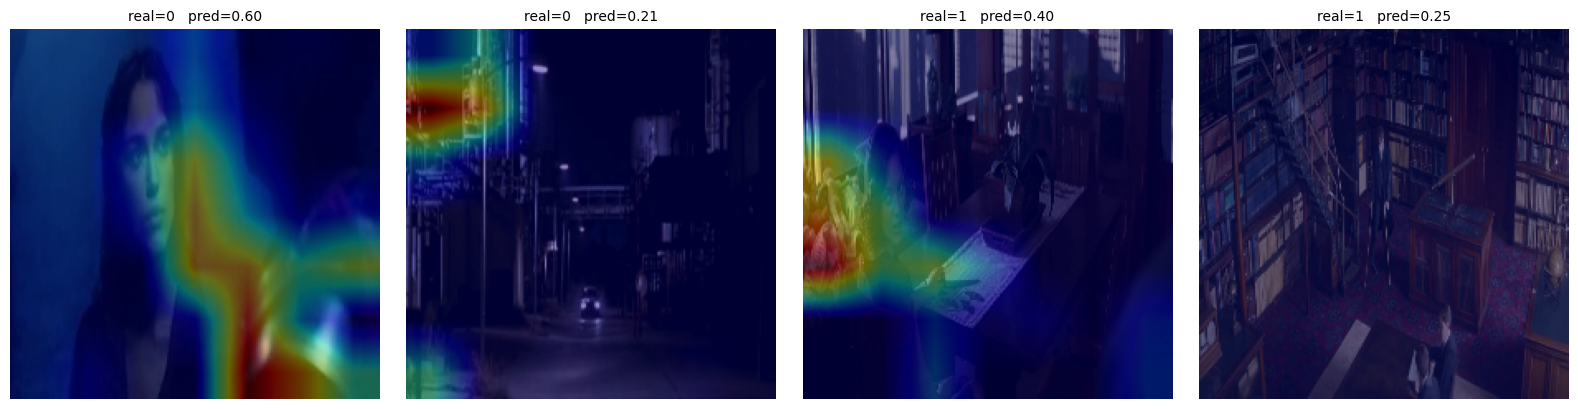

In [35]:
base = [l for l in model.layers if 'resnet' in l.name.lower()][0]
head = model.layers[model.layers.index(base) + 1:]   # GAP + Dense(64) + Dense(1)

def gradcam(path):
    img = tf.image.resize(tf.io.decode_jpeg(tf.io.read_file(path), channels=3), [224, 224])
    x = preprocess_input(tf.expand_dims(img, 0))

    with tf.GradientTape() as tape:
        conv = base(x)                    # (1, 7, 7, 2048)
        tape.watch(conv)
        out = conv
        for layer in head:
            out = layer(out)
        pred = out[0, 0]

    grads = tape.gradient(pred, conv)[0]              # (7, 7, 2048)
    pesos = tf.reduce_mean(grads, axis=(0, 1))        # importancia de cada canal
    cam = tf.nn.relu(tf.reduce_sum(conv[0] * pesos, axis=-1))
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    cam = tf.image.resize(cam[..., None], [224, 224])[..., 0]
    return img.numpy().astype('uint8'), cam.numpy(), float(pred)


ejemplos = (test_df[test_df['image_path'].str.contains('__histogram')]
            .sort_values('memorable').groupby('memorable').head(2))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (_, row) in zip(axes, ejemplos.iterrows()):
    img, cam, p = gradcam(row['image_path'])
    ax.imshow(img)
    ax.imshow(cam, cmap='jet', alpha=0.4)
    ax.set_title(f"real={row['memorable']}   pred={p:.2f}", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

GradCAM revela qué mira el modelo. Los mapas se encienden sobre zonas de alta luminancia —un cartel iluminado, un reflejo sobre un escritorio— y no sobre contenido semántico. El único caso que atiende una cara es justamente uno de los que falla. El modelo responde a propiedades fotométricas de bajo nivel, no a los elementos con memorabilidad. Acierta 1 de 4 ejemplos y comprime sus predicciones entre 0.21 y 0.60, sesgadas hacia "no memorable". Esto explica el techo observado: features genéricos de ImageNet sin datos suficientes para especializarlos.

# **19 - Resultados finales**

In [36]:
# 19: tabla final de resultados
resultados = pd.DataFrame([
    ('1 frame, 10 épocas fijas',          'split 80/20',        0.570,  None,  None),
    ('1 frame, early stopping',           'split 80/20',        0.530,  None,  None),
    ('1 frame, augmentation + ES',        'split 80/20',        0.540,  None,  None),
    ('4 frames, promedio de predicciones','split 80/20',        0.580,  None,  None),
    ('ResNet50 + LogReg',                 '5-fold',             0.579, 0.601,  None),
    ('ResNet50 + LogReg',                 '5-fold x película',  0.541, 0.548,  None),
    ('ResNet50 + LogReg',                 'GroupKFold x película', None, 0.574, 0.163),
    ('ResNet50 + Ridge (score continuo)', 'GroupKFold x película', None, 0.593, 0.207),
    ('EfficientNetB0 + Ridge (score)',    'GroupKFold x película', None, 0.594, 0.190),
], columns=['modelo', 'evaluación', 'accuracy', 'roc_auc', 'spearman'])

display(resultados)
print('baseline trivial (accuracy):', round(max(y.mean(), 1 - y.mean()), 3))

,modelo,evaluación,accuracy,roc_auc,spearman
0,"1 frame, 10 épocas fijas",split 80/20,0.570,NaN,NaN
1,"1 frame, early stopping",split 80/20,0.530,NaN,NaN
2,"1 frame, augmentation + ES",split 80/20,0.540,NaN,NaN
3,"4 frames, promedio de predicciones",split 80/20,0.580,NaN,NaN
4,ResNet50 + LogReg,5-fold,0.579,0.601,NaN
5,ResNet50 + LogReg,5-fold x película,0.541,0.548,NaN
6,ResNet50 + LogReg,GroupKFold x película,NaN,0.574,0.163
7,ResNet50 + Ridge (score continuo),GroupKFold x película,NaN,0.593,0.207
8,EfficientNetB0 + Ridge (score),GroupKFold x película,NaN,0.594,0.190


baseline trivial (accuracy): 0.561


# **CONCLUSIONES**

El mejor modelo en el ejercicio realizado es una regresión Ridge sobre embeddings de ResNet50 congelada, agregados por secuencia y evaluada con validación cruzada agrupada por película: ROC-AUC 0.593, Spearman 0.207.

**El hallazgo principal es metodológico**

Los primeros cuatro experimentos reportaban accuracy entre 0.53 y 0.58 y parecían mostrar diferencias entre técnicas. No las había. Dos sesgos independientes distorsionaban esos números:

Test demasiado chico. Con 132 secuencias, el intervalo de confianza del 95% es de ±8.5 puntos: los cuatro experimentos eran estadísticamente indistinguibles entre sí (z = 0.82, p ≈ 0.41) y todos contenían al baseline trivial. Las conclusiones intermedias ("augmentation mejoró", "early stopping empeoró") leían ruido de muestreo.

Fuga de datos por película. Las 660 secuencias provienen de solo 98 películas, unas 7 por film. Al no agrupar los folds, el modelo podía reconocer la película en lugar de medir memorabilidad. Corregirlo bajó el AUC de 0.601 a 0.548-0.574: aproximadamente la mitad de la señal aparente era fuga.

Ninguno de los dos sesgos era visible sin cambiar el esquema de evaluación, y ambos apuntaban en direcciones distintas.

**Por qué el modelo no mejora**

El tamaño efectivo del dataset no son 660 secuencias sino ~98 películas: las 7 secuencias de un mismo film no son observaciones independientes. Tres evidencias convergen en que el cuello de botella son los datos, no la arquitectura:

ResNet50 y EfficientNetB0, arquitecturas distintas, rinden igual (AUC 0.593 vs 0.594).
Regularización, augmentation y multi-frame no movieron el resultado.
GradCAM muestra que el modelo atiende a luminancia y contraste, no a contenido semántico (caras, personas, objetos inusuales), que es lo que la literatura asocia con memorabilidad.

Por esa razón se descartó el fine-tuning: descongelar ResNet50 con ~98 unidades independientes sobreajustaría con casi total seguridad.

**Decisiones que sí mejoraron el resultado**

Regresión sobre memorability_score en vez de la etiqueta binaria: +0.019 AUC y +0.044 Spearman. Binarizar descarta información —dos videos con score 0.49 y 0.51 son casi idénticos pero se tratan como clases opuestas—. (No se testeó significancia estadística.)
ROC-AUC en lugar de accuracy. La accuracy con umbral fijo en 0.5 quedaba por debajo del baseline mientras el AUC estaba por encima del azar: el modelo ordenaba mejor que una moneda, pero el umbral no estaba calibrado.
Precomputar los embeddings. Con el backbone congelado los features no cambian entre épocas; extraerlos una sola vez permitió pasar de un experimento por sesión a validación cruzada completa en segundos.

**Limitaciones y trabajo futuro**

98 películas independientes son pocas. El desafío MediaEval original alcanza Spearman ~0.5 con 8.000-10.000 videos; 0.207 con esta escala es un resultado proporcionado.
Los frames seleccionados por el método del histograma resultaron oscuros y de bajo contraste en varios casos: el criterio de selección podría no ser el óptimo para esta tarea.
El TP usa solo la modalidad imagen. El desafío completo incluye audio y texto, que aportan señal complementaria.
Con más datos, el fine-tuning y las arquitecturas temporales (CNN+LSTM sobre la secuencia de frames) serían los siguientes pasos naturales.